In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import joblib

In [6]:
df = pd.read_csv('/home/susan/Desktop/AI/Lab3/bbc_news_dataset.csv')
X = df['Text']
y = df['Category']
category_names = df['Category'].unique()

In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity


=== Task 1: Classification Report ===
               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.90      0.94        58

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298



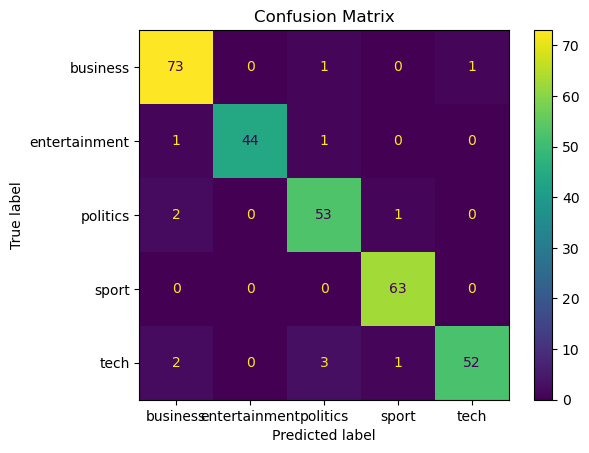

In [8]:
# ---------- Task 1: Base model + evaluation ----------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = make_pipeline(TfidfVectorizer(stop_words='english'), MultinomialNB())
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("=== Task 1: Classification Report ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=model.classes_).plot()
plt.title("Confusion Matrix")
plt.show()

In [9]:
# ---------- Task 2: TF-IDF param experiments ----------
print("\n=== Task 2: TF-IDF Parameter Tuning ===")
params_list = [
    {'max_features': 3000},
    {'ngram_range': (1,2)},
    {'min_df': 2, 'max_df': 0.9},
]
for p in params_list:
    m = make_pipeline(TfidfVectorizer(stop_words='english', **p), MultinomialNB())
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f"Params {p} -> Accuracy: {acc:.4f}")


=== Task 2: TF-IDF Parameter Tuning ===
Params {'max_features': 3000} -> Accuracy: 0.9698
Params {'ngram_range': (1, 2)} -> Accuracy: 0.9631
Params {'min_df': 2, 'max_df': 0.9} -> Accuracy: 0.9631


In [10]:
# ---------- Task 3: Predict 5 custom articles ----------
print("\n=== Task 3: Custom Predictions ===")
custom_texts = [
    "The stock market rallied today as tech shares surged.",
    "The football team won the championship after a dramatic final.",
    "The government announced a new policy on taxation.",
    "The new smartphone features an advanced AI chip.",
    "The movie premiere attracted many celebrities last night."
]
preds = model.predict(custom_texts)
for t, p in zip(custom_texts, preds):
    print(f"{p}: {t[:50]}...")


=== Task 3: Custom Predictions ===
business: The stock market rallied today as tech shares surg...
sport: The football team won the championship after a dra...
politics: The government announced a new policy on taxation....
tech: The new smartphone features an advanced AI chip....
entertainment: The movie premiere attracted many celebrities last...


In [11]:
# ---------- Task 4: Save + reload model ----------
joblib.dump(model, 'model.joblib')
loaded_model = joblib.load('model.joblib')
print("\n=== Task 4: Reloaded model prediction ===")
print(loaded_model.predict(["Apple released a new iPhone with improved camera."]))


=== Task 4: Reloaded model prediction ===
['tech']


In [12]:
# ---------- Task 5 & 6: Different train-test splits ----------
print("\n=== Task 5/6: Train-Test Split Comparison ===")
for test_size in [0.3, 0.2, 0.1]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size, random_state=42)
    m = make_pipeline(TfidfVectorizer(stop_words='english'), MultinomialNB())
    m.fit(Xtr, ytr)
    acc = accuracy_score(yte, m.predict(Xte))
    print(f"Split {int((1-test_size)*100)}-{int(test_size*100)} -> Accuracy: {acc:.4f}")


=== Task 5/6: Train-Test Split Comparison ===
Split 70-30 -> Accuracy: 0.9687
Split 80-20 -> Accuracy: 0.9564
Split 90-10 -> Accuracy: 0.9597


In [13]:
# ---------- Task 7 & 8: Cross Validation ----------
print("\n=== Task 7/8: 5-Fold Cross Validation ===")
cv_model = make_pipeline(TfidfVectorizer(stop_words='english'), MultinomialNB())
scores = cross_val_score(cv_model, X, y, cv=5)
print("Fold Accuracies:", scores)
print(f"Mean Accuracy: {scores.mean():.4f}, Std Dev: {scores.std():.4f}")
# Discuss: low std dev (close to 0) => stable model across folds


=== Task 7/8: 5-Fold Cross Validation ===
Fold Accuracies: [0.96308725 0.95302013 0.96979866 0.97986577 0.96644295]
Mean Accuracy: 0.9664, Std Dev: 0.0088


In [14]:
# ---------- Task 9: Model comparison table ----------
print("\n=== Task 9: Model Comparison ===")
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC()
}
results = []
for name, clf in models.items():
    pipe = make_pipeline(TfidfVectorizer(stop_words='english'), clf)
    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    pred = pipe.predict(X_test)
    pred_time = time.time() - t0

    acc = accuracy_score(y_test, pred)
    results.append([name, acc, train_time, pred_time])

comparison_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Training Time (s)", "Prediction Time (s)"])
print(comparison_df)


=== Task 9: Model Comparison ===
                 Model  Accuracy  Training Time (s)  Prediction Time (s)
0          Naive Bayes  0.956376           0.340388             0.069315
1  Logistic Regression  0.966443           1.661290             0.078614
2                  SVM  0.963087           2.572818             0.365849


In [15]:
# ---------- Task 10: News Recommendation Prototype ----------
print("\n=== Task 10: Recommendation Prototype ===")
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['Text'])



=== Task 10: Recommendation Prototype ===


In [16]:
def recommend_similar(article_text, top_n=3):
    predicted_cat = model.predict([article_text])[0]
    same_cat_idx = df[df['Category'] == predicted_cat].index
    article_vec = tfidf.transform([article_text])
    sims = cosine_similarity(article_vec, tfidf_matrix[same_cat_idx]).flatten()
    top_idx = sims.argsort()[-top_n:][::-1]
    similar_articles = df.loc[same_cat_idx[top_idx], 'Text'].values
    return predicted_cat, similar_articles

In [17]:
sample = "The economy grew steadily as new investments poured in."
cat, recs = recommend_similar(sample)
print(f"Predicted category: {cat}")
for i, r in enumerate(recs, 1):
    print(f"Similar {i}: {r[:80]}...")

Predicted category: business
Similar 1: japan economy slides to recession the japanese economy has officially gone back ...
Similar 2: australia rates at four year high australia is raising its benchmark interest ra...
Similar 3: singapore growth at 8.1% in 2004 singapore s economy grew by 8.1% in 2004  its b...


In [18]:
# Save recommendation artifacts for Flask use
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')
joblib.dump(tfidf_matrix, 'tfidf_matrix.joblib')
df.to_csv('df_for_recommend.csv', index=False)